SMART CITY PROJECT - Data Analysis (English Figures)
Person / Vehicle Detection Statistics
Based on VIRAT / MEVA-style outputs

[Step 1] Load detection data
Generating mock detection data...
Done. Total detections: 58717
Persons: 22546
Vehicles: 36171

Data overview:
Total detections: 58717
Time range: 0.0 - 299.9 seconds
Classes: ['person' 'vehicle']
Vehicle types: ['car' 'truck' 'bus' 'motorcycle']

[Step 2] Compute statistics

[Step 3] Generate figures


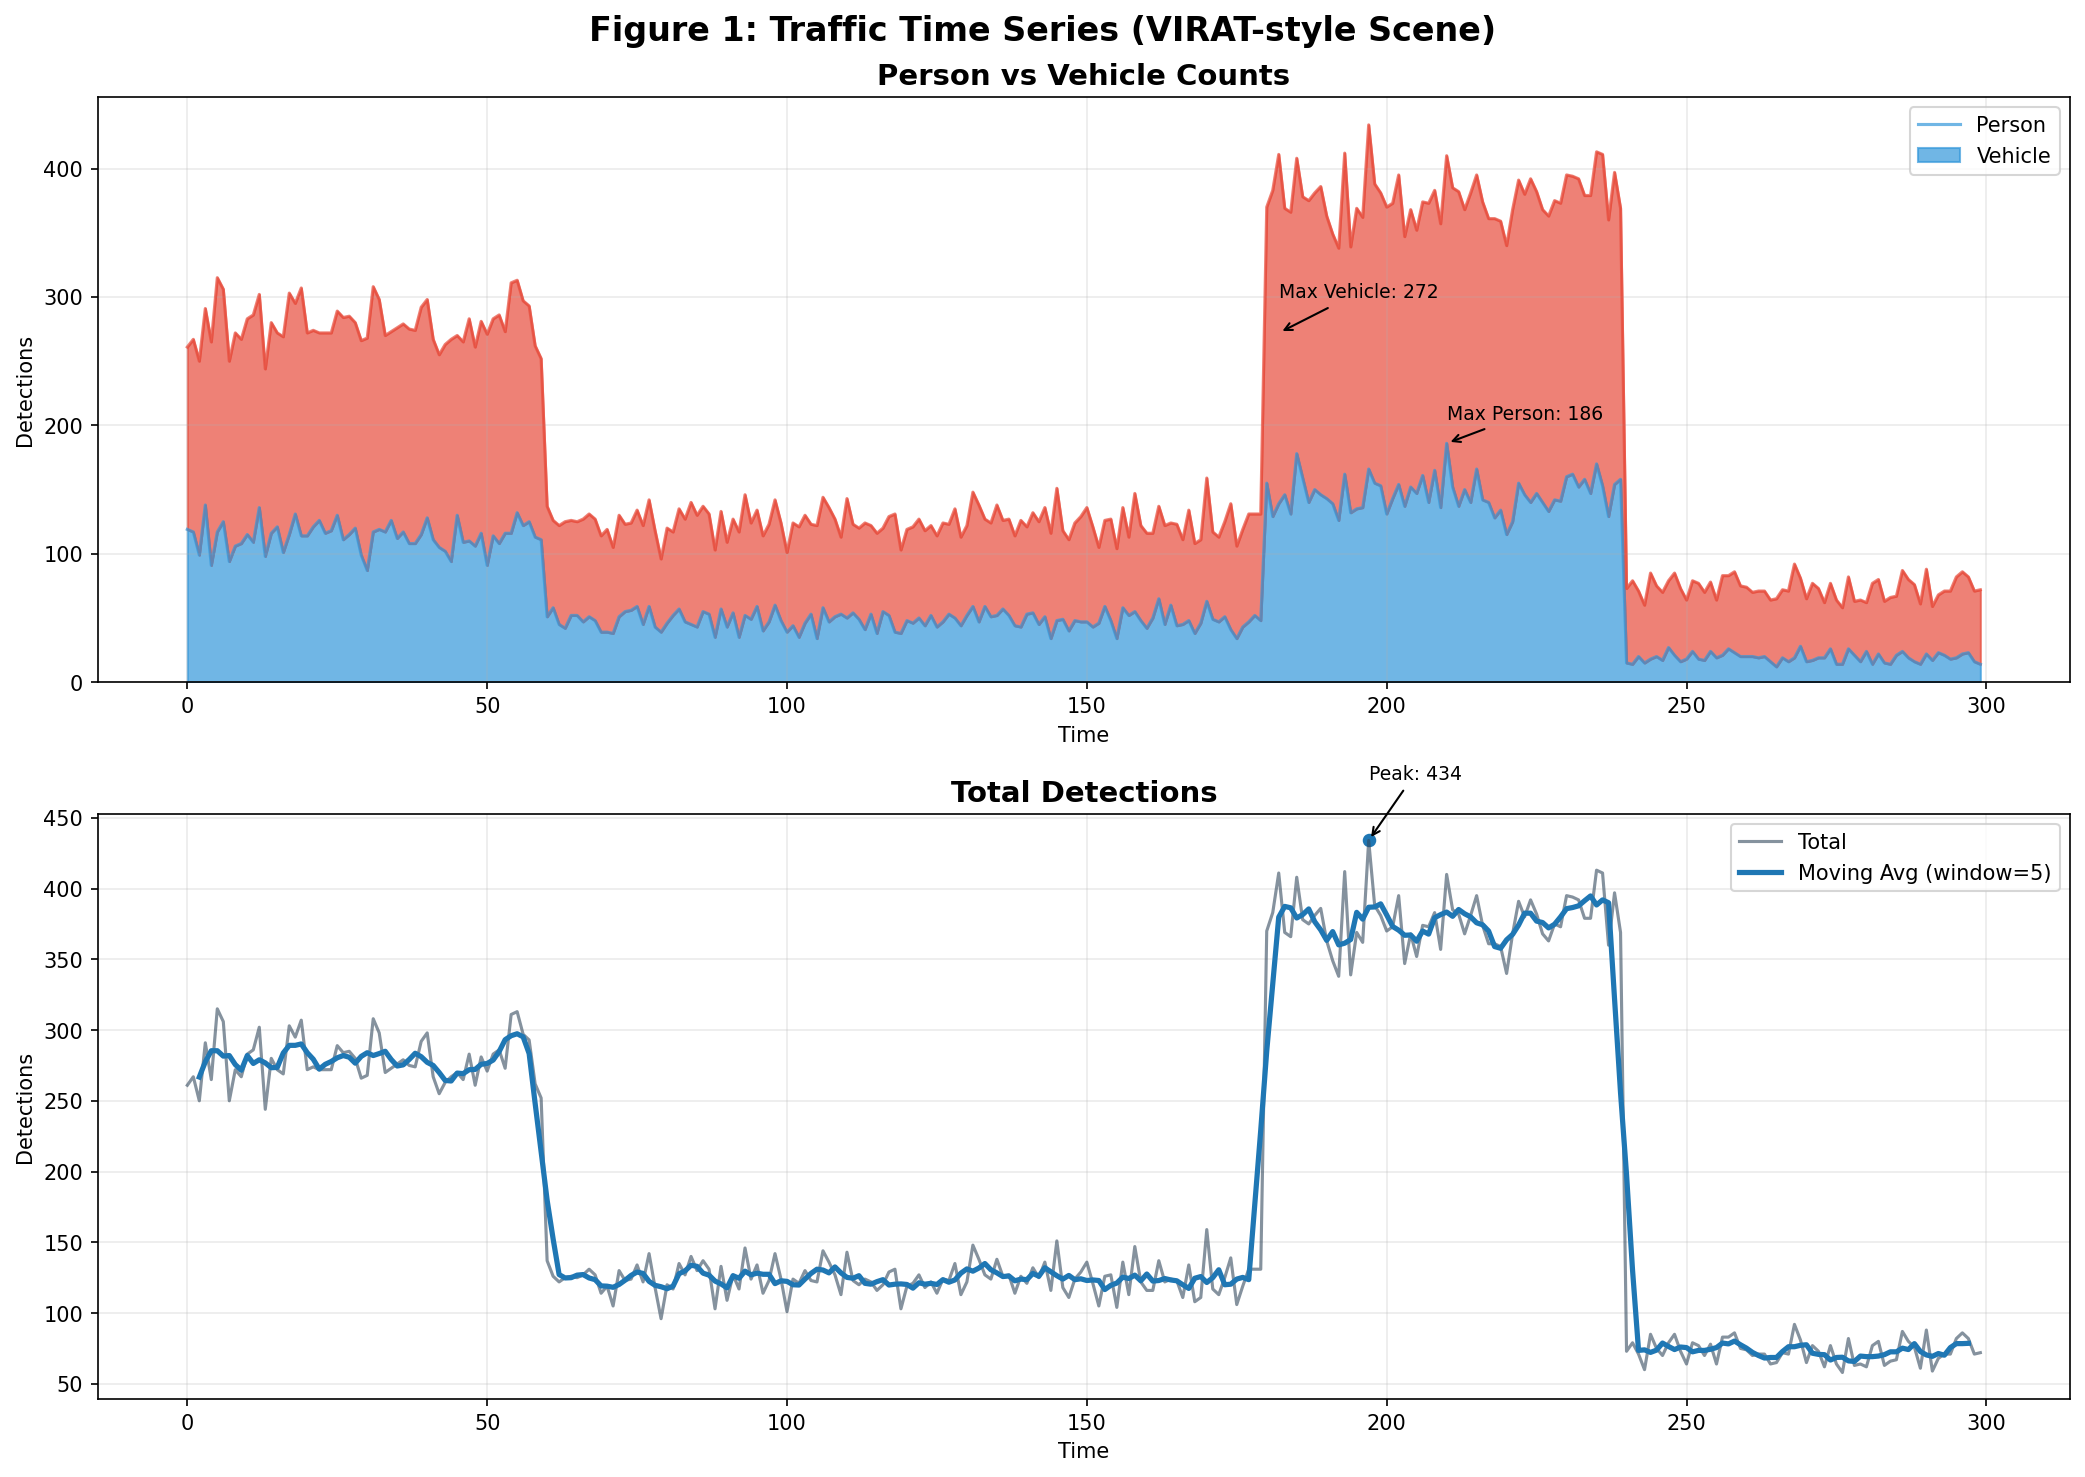

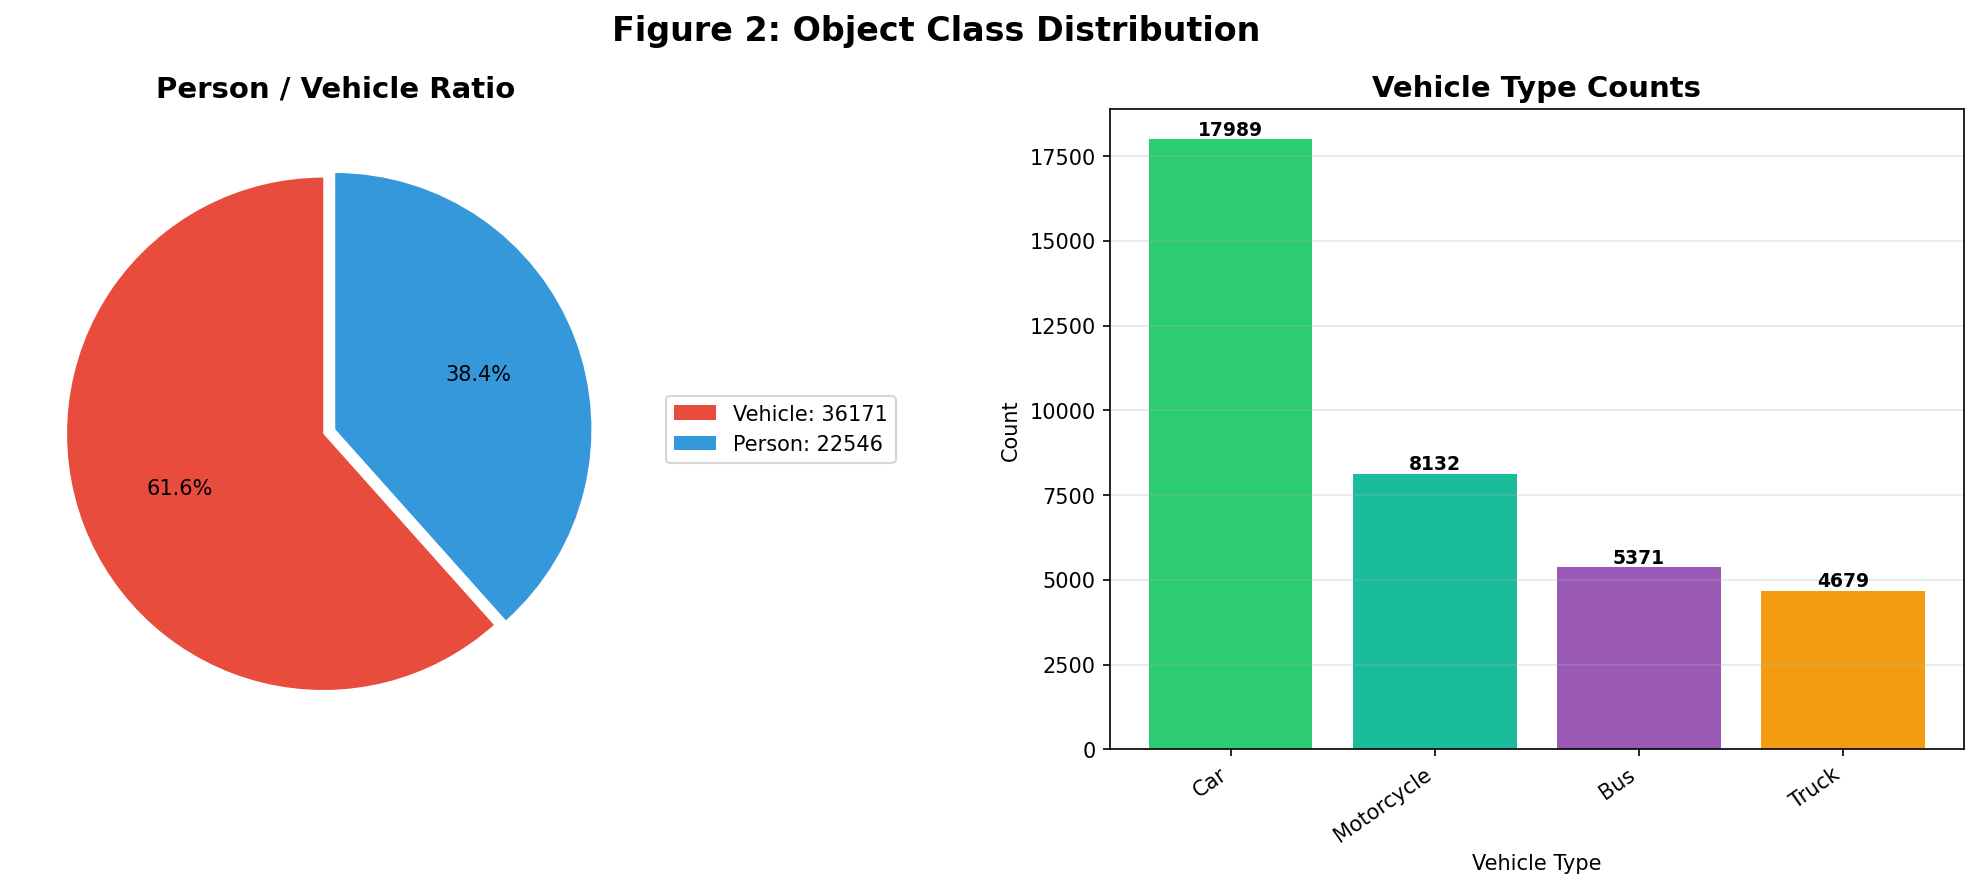

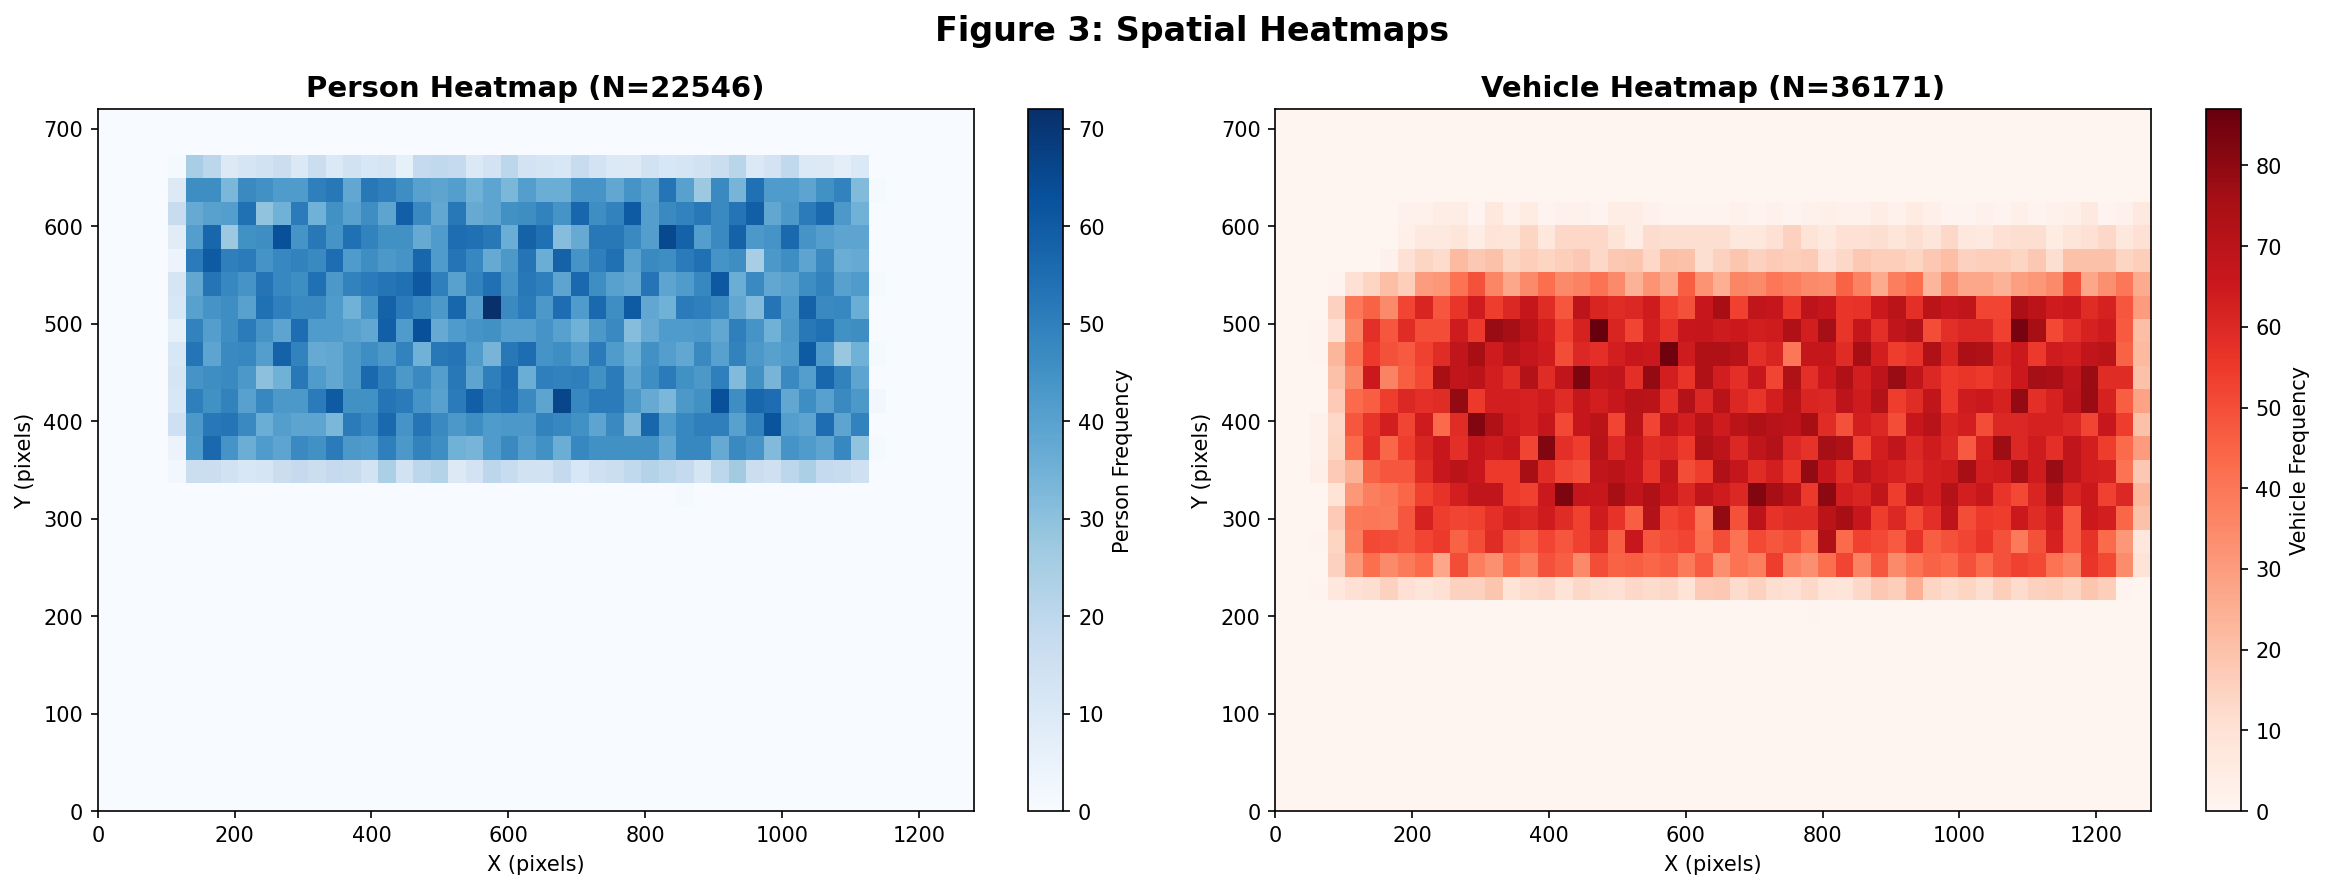

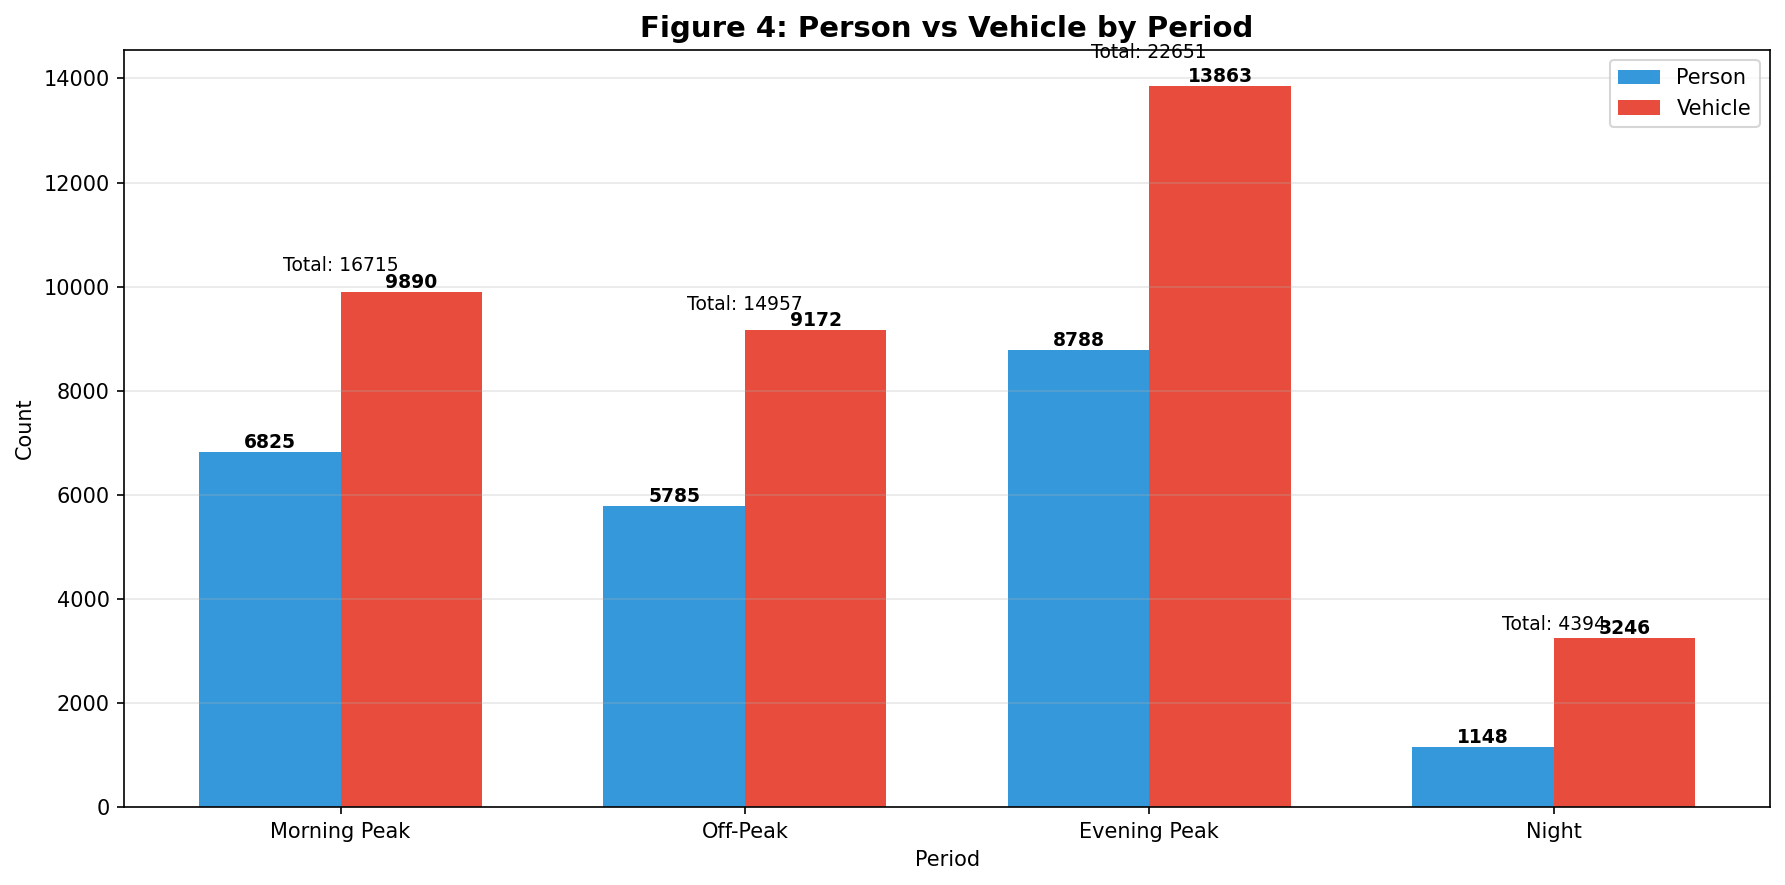

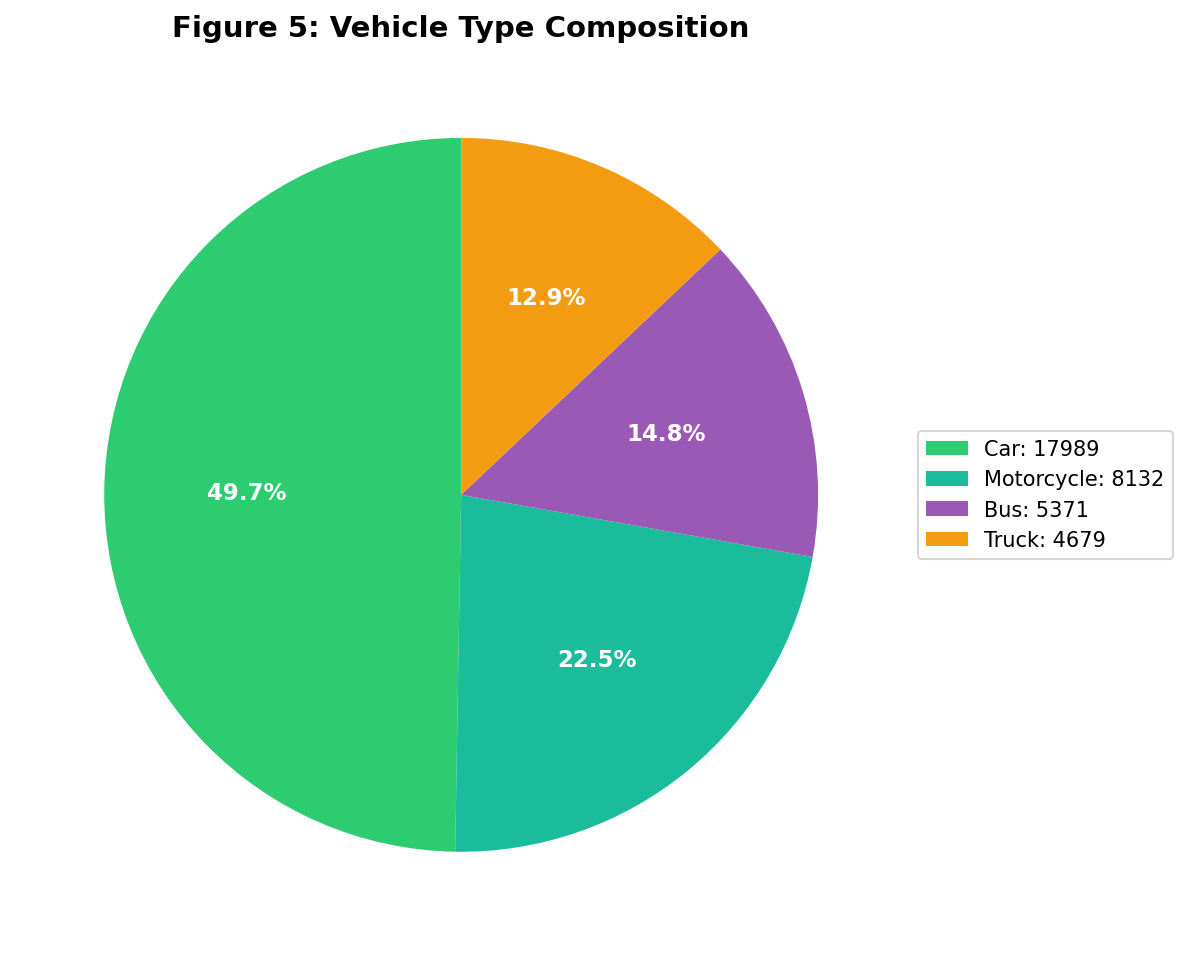


Summary
Total detections: 58717
  Person:  22546 (38.4%)
  Vehicle: 36171 (61.6%)

Traffic:
Average total: 195.72 objects/second
Peak total:    434 objects/second
Peak threshold (90th): 20276.60

Person/Vehicle ratio:
Person ratio:  38.4%
Vehicle ratio: 61.6%
Persons per vehicle: 0.62

Vehicle composition:
  car: 17989 (49.7%)
  motorcycle: 8132 (22.5%)
  bus: 5371 (14.8%)
  truck: 4679 (12.9%)

Done. Figures saved as PNG files in the Colab working directory.
Saved: period_statistics.csv
Saved: vehicle_composition.csv
Saved: detection_summary.csv

Tip: To use real detections, do:
loader = VideoDataLoader()
df = loader.load_from_json('your_file.json')
stats = TrafficStatistics(df)
... then call viz methods as above.


In [2]:
# ============================================================================
# Smart City Project - 数据分析代码
# 负责：数据分析部分
# 基于：VIRAT/MEVA数据集的人员和车辆检测结果
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# ============================
# Global plotting settings (English + clean style)
# ============================
plt.rcParams['font.family'] = 'DejaVu Sans'  # safe default in Colab
plt.rcParams['axes.unicode_minus'] = False

# =============================================================================
# 1. Data loader
# =============================================================================

class VideoDataLoader:
    """Load YOLO-like detection results, or generate mock data."""

    def __init__(self):
        self.detections_df = None
        self.frame_rate = 30  # default fps

    def generate_mock_data(self, duration_seconds=300, frame_rate=30):
        """
        Generate mock detections:
          - classes: person, vehicle (car/truck/bus/motorcycle)
          - periods: Morning peak / Off-peak / Evening peak / Night
        """
        print("Generating mock detection data...")
        np.random.seed(42)

        self.frame_rate = frame_rate
        total_frames = duration_seconds * frame_rate
        timestamps = np.linspace(0, duration_seconds, total_frames)

        def get_traffic_intensity(t):
            if t < 60:      # Morning peak
                return {'person': 12, 'car': 8, 'truck': 2, 'bus': 3, 'motorcycle': 4}
            elif t < 180:   # Off-peak
                return {'person': 5, 'car': 4, 'truck': 1, 'bus': 1, 'motorcycle': 2}
            elif t < 240:   # Evening peak
                return {'person': 15, 'car': 12, 'truck': 3, 'bus': 4, 'motorcycle': 5}
            else:           # Night
                return {'person': 2, 'car': 3, 'truck': 1, 'bus': 0.5, 'motorcycle': 1}

        records = []
        vehicle_types = ['car', 'truck', 'bus', 'motorcycle']

        for i, t in enumerate(timestamps[::3]):  # sample every 3 frames
            intensity = get_traffic_intensity(t)
            frame_id = f"frame_{i:06d}"

            # persons
            n_persons = np.random.poisson(intensity['person'])
            for _ in range(n_persons):
                confidence = np.random.beta(8, 1.5)
                if confidence < 0.6:
                    continue
                x1 = np.random.uniform(100, 1100)
                y1 = np.random.uniform(300, 600)
                w = np.random.uniform(30, 60)
                h = np.random.uniform(70, 140)
                records.append({
                    'frame_id': frame_id,
                    'timestamp': float(t),
                    'class': 'person',
                    'class_detail': 'person',
                    'confidence': float(confidence),
                    'bbox_x1': float(x1),
                    'bbox_y1': float(y1),
                    'bbox_x2': float(x1 + w),
                    'bbox_y2': float(y1 + h),
                    'width': float(w),
                    'height': float(h),
                    'area': float(w * h),
                    'is_vehicle': False
                })

            # vehicles
            for vtype in vehicle_types:
                n_vehicles = np.random.poisson(intensity[vtype])
                for _ in range(n_vehicles):
                    confidence = np.random.beta(7, 1.2)
                    if confidence < 0.6:
                        continue
                    x1 = np.random.uniform(50, 1200)
                    y1 = np.random.uniform(200, 500)

                    if vtype == 'car':
                        w, h = np.random.uniform(80, 150), np.random.uniform(60, 100)
                    elif vtype == 'truck':
                        w, h = np.random.uniform(200, 350), np.random.uniform(120, 200)
                    elif vtype == 'bus':
                        w, h = np.random.uniform(250, 400), np.random.uniform(150, 250)
                    else:
                        w, h = np.random.uniform(40, 70), np.random.uniform(30, 60)

                    records.append({
                        'frame_id': frame_id,
                        'timestamp': float(t),
                        'class': 'vehicle',
                        'class_detail': vtype,
                        'confidence': float(confidence),
                        'bbox_x1': float(x1),
                        'bbox_y1': float(y1),
                        'bbox_x2': float(x1 + w),
                        'bbox_y2': float(y1 + h),
                        'width': float(w),
                        'height': float(h),
                        'area': float(w * h),
                        'is_vehicle': True
                    })

        self.detections_df = pd.DataFrame(records)

        self.detections_df['second'] = self.detections_df['timestamp'].astype(int)
        self.detections_df['minute'] = (self.detections_df['timestamp'] / 60).astype(int)
        self.detections_df['period'] = self.detections_df['second'].apply(
            lambda x: 'Morning Peak' if x < 60 else ('Off-Peak' if x < 180 else ('Evening Peak' if x < 240 else 'Night'))
        )

        print(f"Done. Total detections: {len(self.detections_df)}")
        print(f"Persons: {len(self.detections_df[self.detections_df['class']=='person'])}")
        print(f"Vehicles: {len(self.detections_df[self.detections_df['class']=='vehicle'])}")
        return self.detections_df

    def load_from_json(self, json_path):
        """
        Expected JSON:
        {
          "frame_0001": {
            "timestamp": 0.033,
            "detections": [
              {"class":"person","confidence":0.95,"bbox":[x1,y1,x2,y2]},
              {"class":"vehicle","type":"car","confidence":0.89,"bbox":[...]}
            ]
          }
        }
        """
        with open(json_path, 'r') as f:
            data = json.load(f)

        records = []
        for frame_id, frame_data in data.items():
            timestamp = frame_data.get('timestamp', 0)
            for det in frame_data.get('detections', []):
                cls = det['class']
                cls_detail = det.get('type', cls) if cls == 'vehicle' else cls
                x1, y1, x2, y2 = det['bbox']

                records.append({
                    'frame_id': frame_id,
                    'timestamp': float(timestamp),
                    'class': cls,
                    'class_detail': cls_detail,
                    'confidence': float(det['confidence']),
                    'bbox_x1': float(x1),
                    'bbox_y1': float(y1),
                    'bbox_x2': float(x2),
                    'bbox_y2': float(y2),
                    'width': float(x2 - x1),
                    'height': float(y2 - y1),
                    'area': float((x2 - x1) * (y2 - y1)),
                    'is_vehicle': (cls == 'vehicle')
                })

        self.detections_df = pd.DataFrame(records)
        self.detections_df['second'] = self.detections_df['timestamp'].astype(int)
        self.detections_df['minute'] = (self.detections_df['timestamp'] / 60).astype(int)

        print(f"Loaded detections: {len(self.detections_df)}")
        return self.detections_df


# =============================================================================
# 2. Statistics
# =============================================================================

class TrafficStatistics:
    """Compute statistics for person/vehicle traffic."""

    def __init__(self, df):
        self.df = df
        self.stats = {}

    def compute_counts_by_time(self, time_unit='second'):
        """
        Count detections by time unit: second/minute/hour (if hour exists).
        Fix: avoid double-counting vehicles in total.
        """
        class_counts = self.df.groupby([time_unit, 'class']).size().reset_index(name='count')
        pivot_class = class_counts.pivot(index=time_unit, columns='class', values='count').fillna(0)

        # vehicle_total (kept for total computation)
        if 'vehicle' in pivot_class.columns:
            pivot_class['vehicle_total'] = pivot_class['vehicle']

        # vehicle details
        vehicle_df = self.df[self.df['class'] == 'vehicle']
        if not vehicle_df.empty:
            detail_counts = vehicle_df.groupby([time_unit, 'class_detail']).size().reset_index(name='count')
            pivot_detail = detail_counts.pivot(index=time_unit, columns='class_detail', values='count').fillna(0)
            pivot_class = pivot_class.join(pivot_detail, how='outer').fillna(0)

        # total = person + vehicle_total (NO double counting)
        cols = []
        if 'person' in pivot_class.columns:
            cols.append('person')
        if 'vehicle_total' in pivot_class.columns:
            cols.append('vehicle_total')
        pivot_class['total'] = pivot_class[cols].sum(axis=1) if cols else 0

        self.stats['time_counts'] = pivot_class
        self.stats['time_unit'] = time_unit
        return pivot_class

    def compute_peak_times(self, threshold_percentile=90):
        """Find peak times based on total counts."""
        if 'time_counts' not in self.stats:
            self.compute_counts_by_time()

        total_counts = self.stats['time_counts']['total']
        threshold = float(np.percentile(total_counts, threshold_percentile))
        peaks = total_counts[total_counts > threshold]

        self.stats['peak_threshold'] = threshold
        self.stats['peak_times'] = peaks
        self.stats['peak_percentile'] = threshold_percentile
        return peaks

    def compute_vehicle_composition(self):
        """Vehicle type composition."""
        vehicle_df = self.df[self.df['class'] == 'vehicle']
        if vehicle_df.empty:
            return None

        composition = vehicle_df['class_detail'].value_counts()
        composition_pct = vehicle_df['class_detail'].value_counts(normalize=True) * 100

        result = pd.DataFrame({'count': composition, 'percentage': composition_pct})
        self.stats['vehicle_composition'] = result
        return result

    def compute_person_vehicle_ratio(self):
        """Person/vehicle ratio."""
        person_count = int((self.df['class'] == 'person').sum())
        vehicle_count = int((self.df['class'] == 'vehicle').sum())
        total = person_count + vehicle_count
        if total == 0:
            return None

        ratio = {
            'person_count': person_count,
            'vehicle_count': vehicle_count,
            'person_ratio': person_count / total * 100,
            'vehicle_ratio': vehicle_count / total * 100,
            'person_per_vehicle': person_count / vehicle_count if vehicle_count > 0 else float('inf')
        }
        self.stats['pv_ratio'] = ratio
        return ratio

    def compute_period_statistics(self):
        """Stats by period (if 'period' column exists)."""
        if 'period' not in self.df.columns:
            return None

        periods = ['Morning Peak', 'Off-Peak', 'Evening Peak', 'Night']
        out = []
        for p in periods:
            pdf = self.df[self.df['period'] == p]
            if pdf.empty:
                continue

            person_count = int((pdf['class'] == 'person').sum())
            vehicle_count = int((pdf['class'] == 'vehicle').sum())

            row = {
                'period': p,
                'total_objects': int(len(pdf)),
                'persons': person_count,
                'vehicles': vehicle_count,
                'person_pct': person_count / len(pdf) * 100 if len(pdf) else 0,
                'vehicle_pct': vehicle_count / len(pdf) * 100 if len(pdf) else 0
            }

            vdf = pdf[pdf['class'] == 'vehicle']
            if not vdf.empty:
                for vtype in ['car', 'truck', 'bus', 'motorcycle']:
                    row[f'{vtype}_count'] = int((vdf['class_detail'] == vtype).sum())

            out.append(row)

        df_out = pd.DataFrame(out)
        self.stats['period_stats'] = df_out
        return df_out


# =============================================================================
# 3. Visualization (ENGLISH + annotations)
# =============================================================================

class TrafficVisualizer:
    """Generate clean figures for PPT with English labels + numeric annotations."""

    def __init__(self):
        self.colors = {
            'person': '#3498db',
            'vehicle': '#e74c3c',
            'car': '#2ecc71',
            'truck': '#f39c12',
            'bus': '#9b59b6',
            'motorcycle': '#1abc9c',
            'total': '#34495e'
        }

    # -------- helpers --------
    @staticmethod
    def _annotate_bars(ax, bars, fmt='{:.0f}', fontsize=9):
        for b in bars:
            h = b.get_height()
            if h is None:
                continue
            ax.text(b.get_x() + b.get_width()/2, h, fmt.format(h),
                    ha='center', va='bottom', fontsize=fontsize, fontweight='bold')

    @staticmethod
    def _nice_grid(ax):
        ax.grid(True, alpha=0.25)

    def plot_time_series(self, count_df, title="Figure 1: Traffic Over Time", save_path=None):
        """
        Figure 1:
          - top: stacked area (Person vs Vehicle)
          - bottom: Total + moving average + peak threshold annotation (if provided later)
        """
        fig, axes = plt.subplots(2, 1, figsize=(14, 10), dpi=150)

        # Top: stacked area
        if 'person' in count_df.columns and 'vehicle' in count_df.columns:
            plot_df = count_df[['person', 'vehicle']].copy()
            plot_df.plot.area(ax=axes[0], alpha=0.7,
                              color=[self.colors['person'], self.colors['vehicle']])
            axes[0].set_title("Person vs Vehicle Counts", fontsize=14, fontweight='bold')
            axes[0].set_xlabel("Time")
            axes[0].set_ylabel("Detections")
            axes[0].legend(['Person', 'Vehicle'])
            self._nice_grid(axes[0])

            # annotate max points (person/vehicle)
            for col, label in [('person', 'Person'), ('vehicle', 'Vehicle')]:
                if col in plot_df.columns and len(plot_df) > 0:
                    idxmax = plot_df[col].idxmax()
                    vmax = plot_df.loc[idxmax, col]
                    axes[0].annotate(f"Max {label}: {int(vmax)}",
                                     xy=(idxmax, vmax),
                                     xytext=(idxmax, vmax + max(1, vmax*0.1)),
                                     arrowprops=dict(arrowstyle="->", lw=1),
                                     fontsize=9)

        # Bottom: total + MA
        if 'total' in count_df.columns:
            axes[1].plot(count_df.index, count_df['total'],
                         color=self.colors['total'], linewidth=1.5, alpha=0.6, label='Total')

            if len(count_df) > 10:
                ma = count_df['total'].rolling(window=5, center=True).mean()
                axes[1].plot(count_df.index, ma, linewidth=2.5, label='Moving Avg (window=5)')

            # annotate global max
            idxmax = count_df['total'].idxmax()
            vmax = count_df.loc[idxmax, 'total']
            axes[1].scatter([idxmax], [vmax], s=30)
            axes[1].annotate(f"Peak: {int(vmax)}",
                             xy=(idxmax, vmax),
                             xytext=(idxmax, vmax + max(1, vmax*0.1)),
                             arrowprops=dict(arrowstyle="->", lw=1),
                             fontsize=9)

            axes[1].set_title("Total Detections", fontsize=14, fontweight='bold')
            axes[1].set_xlabel("Time")
            axes[1].set_ylabel("Detections")
            axes[1].legend()
            self._nice_grid(axes[1])

        plt.suptitle(title, fontsize=16, fontweight='bold')
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    def plot_class_distribution(self, df, title="Figure 2: Class Distribution", save_path=None):
        """
        Figure 2:
          - left: pie (Person vs Vehicle) with legend (label + count)
          - right: bar (vehicle types) with counts on bars
        """
        fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=150)

        # Pie
        class_counts = df['class'].value_counts()
        label_map = {'person': 'Person', 'vehicle': 'Vehicle'}
        pie_labels = [label_map.get(x, str(x).title()) for x in class_counts.index]

        wedges, texts, autotexts = axes[0].pie(
            class_counts.values,
            labels=None,
            autopct='%1.1f%%',
            colors=[self.colors.get(k, '#95a5a6') for k in class_counts.index],
            startangle=90,
            explode=tuple([0.05] + [0]*(len(class_counts)-1)) if len(class_counts) > 1 else None
        )
        axes[0].set_title("Person / Vehicle Ratio", fontsize=14, fontweight='bold')

        legend_labels = [f"{lab}: {val}" for lab, val in zip(pie_labels, class_counts.values)]
        axes[0].legend(wedges, legend_labels, loc="center left", bbox_to_anchor=(1.0, 0.5))

        for t in autotexts:
            t.set_fontsize(10)

        # Bar: vehicle types
        vehicle_df = df[df['class'] == 'vehicle']
        axes[1].set_title("Vehicle Type Counts", fontsize=14, fontweight='bold')
        axes[1].set_xlabel("Vehicle Type")
        axes[1].set_ylabel("Count")

        if not vehicle_df.empty:
            vtype_counts = vehicle_df['class_detail'].value_counts()
            vlabel = {'car': 'Car', 'truck': 'Truck', 'bus': 'Bus', 'motorcycle': 'Motorcycle'}
            xticklabels = [vlabel.get(v, str(v).title()) for v in vtype_counts.index]

            bars = axes[1].bar(
                range(len(vtype_counts)),
                vtype_counts.values,
                color=[self.colors.get(v, '#95a5a6') for v in vtype_counts.index]
            )
            axes[1].set_xticks(range(len(vtype_counts)))
            axes[1].set_xticklabels(xticklabels, rotation=35, ha='right')
            axes[1].grid(True, alpha=0.3, axis='y')
            self._annotate_bars(axes[1], bars, fmt='{:.0f}', fontsize=9)
        else:
            axes[1].text(0.5, 0.5, "No vehicle detections", ha="center", va="center")
            axes[1].set_xticks([])
            axes[1].set_yticks([])

        plt.suptitle(title, fontsize=16, fontweight='bold')
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    def plot_heatmap(self, df, title="Figure 3: Spatial Heatmap", save_path=None,
                     frame_width=1280, frame_height=720):
        """
        Figure 3:
          - left: person 2D histogram heatmap
          - right: vehicle 2D histogram heatmap
        Adds colorbar + axis labels in English.
        """
        fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=150)

        # Person heatmap
        person_df = df[df['class'] == 'person']
        if not person_df.empty:
            px = (person_df['bbox_x1'] + person_df['bbox_x2']) / 2
            py = (person_df['bbox_y1'] + person_df['bbox_y2']) / 2

            heat_p, _, _ = np.histogram2d(px, py, bins=[50, 30],
                                         range=[[0, frame_width], [0, frame_height]])
            im1 = axes[0].imshow(heat_p.T, origin='lower', aspect='auto',
                                 extent=[0, frame_width, 0, frame_height], cmap='Blues')
            cb1 = plt.colorbar(im1, ax=axes[0])
            cb1.set_label("Person Frequency")
            axes[0].set_title(f"Person Heatmap (N={len(person_df)})", fontsize=14, fontweight='bold')
            axes[0].set_xlabel("X (pixels)")
            axes[0].set_ylabel("Y (pixels)")
        else:
            axes[0].text(0.5, 0.5, "No person detections", ha="center", va="center")
            axes[0].set_axis_off()

        # Vehicle heatmap
        vehicle_df = df[df['class'] == 'vehicle']
        if not vehicle_df.empty:
            vx = (vehicle_df['bbox_x1'] + vehicle_df['bbox_x2']) / 2
            vy = (vehicle_df['bbox_y1'] + vehicle_df['bbox_y2']) / 2

            heat_v, _, _ = np.histogram2d(vx, vy, bins=[50, 30],
                                         range=[[0, frame_width], [0, frame_height]])
            im2 = axes[1].imshow(heat_v.T, origin='lower', aspect='auto',
                                 extent=[0, frame_width, 0, frame_height], cmap='Reds')
            cb2 = plt.colorbar(im2, ax=axes[1])
            cb2.set_label("Vehicle Frequency")
            axes[1].set_title(f"Vehicle Heatmap (N={len(vehicle_df)})", fontsize=14, fontweight='bold')
            axes[1].set_xlabel("X (pixels)")
            axes[1].set_ylabel("Y (pixels)")
        else:
            axes[1].text(0.5, 0.5, "No vehicle detections", ha="center", va="center")
            axes[1].set_axis_off()

        plt.suptitle(title, fontsize=16, fontweight='bold')
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    def plot_period_comparison(self, period_stats_df, title="Figure 4: Period Comparison", save_path=None):
        """
        Figure 4:
          - grouped bars: persons vs vehicles by period
          - numeric labels on each bar
        """
        if period_stats_df is None or period_stats_df.empty:
            return

        fig, ax = plt.subplots(figsize=(12, 6), dpi=150)

        x = np.arange(len(period_stats_df))
        width = 0.35

        p_bars = ax.bar(x - width/2, period_stats_df['persons'], width,
                        label='Person', color=self.colors['person'])
        v_bars = ax.bar(x + width/2, period_stats_df['vehicles'], width,
                        label='Vehicle', color=self.colors['vehicle'])

        ax.set_xlabel("Period")
        ax.set_ylabel("Count")
        ax.set_title(title, fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(period_stats_df['period'])
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')

        self._annotate_bars(ax, p_bars, fmt='{:.0f}', fontsize=9)
        self._annotate_bars(ax, v_bars, fmt='{:.0f}', fontsize=9)

        # Add total label above each group
        for i in range(len(period_stats_df)):
            total = int(period_stats_df.loc[i, 'total_objects'])
            ax.text(i, max(period_stats_df.loc[i, 'persons'], period_stats_df.loc[i, 'vehicles']) + max(1, total*0.02),
                    f"Total: {total}", ha='center', va='bottom', fontsize=9)

        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    def plot_vehicle_composition_pie(self, composition_df, title="Figure 5: Vehicle Composition", save_path=None):
        """
        Figure 5:
          - pie chart for vehicle composition
          - English labels + legend with counts + % already on pie
        """
        if composition_df is None or composition_df.empty:
            return

        fig, ax = plt.subplots(figsize=(8, 8), dpi=150)

        label_map = {'car': 'Car', 'truck': 'Truck', 'bus': 'Bus', 'motorcycle': 'Motorcycle'}
        labels = [label_map.get(v, str(v).title()) for v in composition_df.index]
        colors = [self.colors.get(v, '#95a5a6') for v in composition_df.index]

        wedges, texts, autotexts = ax.pie(
            composition_df['count'].values,
            labels=None,
            autopct='%1.1f%%',
            colors=colors,
            startangle=90
        )

        # Legend (label + count)
        legend_labels = [f"{lab}: {int(cnt)}" for lab, cnt in zip(labels, composition_df['count'].values)]
        ax.legend(wedges, legend_labels, loc="center left", bbox_to_anchor=(1.0, 0.5))

        for t in autotexts:
            t.set_color('white')
            t.set_fontsize(11)
            t.set_fontweight('bold')

        ax.set_title(title, fontsize=14, fontweight='bold')
        plt.tight_layout()

        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()


# =============================================================================
# 4. Main execution
# =============================================================================

def main():
    print("="*70)
    print("SMART CITY PROJECT - Data Analysis (English Figures)")
    print("Person / Vehicle Detection Statistics")
    print("Based on VIRAT / MEVA-style outputs")
    print("="*70)

    # Step 1: Load data
    print("\n[Step 1] Load detection data")
    loader = VideoDataLoader()

    # Mock data (replace with loader.load_from_json(...) for real data)
    df = loader.generate_mock_data(duration_seconds=300, frame_rate=30)

    print("\nData overview:")
    print(f"Total detections: {len(df)}")
    print(f"Time range: {df['timestamp'].min():.1f} - {df['timestamp'].max():.1f} seconds")
    print(f"Classes: {df['class'].unique()}")
    print(f"Vehicle types: {df[df['class']=='vehicle']['class_detail'].unique()}")

    # Step 2: Statistics
    print("\n[Step 2] Compute statistics")
    stats = TrafficStatistics(df)

    second_counts = stats.compute_counts_by_time('second')
    minute_counts = stats.compute_counts_by_time('minute')

    peaks = stats.compute_peak_times(threshold_percentile=90)
    vehicle_comp = stats.compute_vehicle_composition()
    pv_ratio = stats.compute_person_vehicle_ratio()
    period_stats = stats.compute_period_statistics()

    # Step 3: Visualizations
    print("\n[Step 3] Generate figures")
    viz = TrafficVisualizer()

    viz.plot_time_series(
        second_counts,
        title="Figure 1: Traffic Time Series (VIRAT-style Scene)",
        save_path="figure1_timeseries.png"
    )

    viz.plot_class_distribution(
        df,
        title="Figure 2: Object Class Distribution",
        save_path="figure2_class_distribution.png"
    )

    viz.plot_heatmap(
        df,
        title="Figure 3: Spatial Heatmaps",
        save_path="figure3_spatial_heatmap.png",
        frame_width=1280,
        frame_height=720
    )

    if period_stats is not None:
        viz.plot_period_comparison(
            period_stats,
            title="Figure 4: Person vs Vehicle by Period",
            save_path="figure4_period_comparison.png"
        )

    if vehicle_comp is not None:
        viz.plot_vehicle_composition_pie(
            vehicle_comp,
            title="Figure 5: Vehicle Type Composition",
            save_path="figure5_vehicle_composition.png"
        )

    # Print summary (English)
    print("\n" + "="*70)
    print("Summary")
    print("="*70)

    person_n = int((df['class'] == 'person').sum())
    vehicle_n = int((df['class'] == 'vehicle').sum())
    total_n = len(df)

    print(f"Total detections: {total_n}")
    print(f"  Person:  {person_n} ({person_n/total_n*100:.1f}%)")
    print(f"  Vehicle: {vehicle_n} ({vehicle_n/total_n*100:.1f}%)")

    print("\nTraffic:")
    print(f"Average total: {second_counts['total'].mean():.2f} objects/second")
    print(f"Peak total:    {second_counts['total'].max():.0f} objects/second")
    print(f"Peak threshold (90th): {stats.stats.get('peak_threshold', 0):.2f}")

    if pv_ratio is not None:
        print("\nPerson/Vehicle ratio:")
        print(f"Person ratio:  {pv_ratio['person_ratio']:.1f}%")
        print(f"Vehicle ratio: {pv_ratio['vehicle_ratio']:.1f}%")
        if np.isfinite(pv_ratio['person_per_vehicle']):
            print(f"Persons per vehicle: {pv_ratio['person_per_vehicle']:.2f}")

    if vehicle_comp is not None:
        print("\nVehicle composition:")
        for vtype, row in vehicle_comp.iterrows():
            print(f"  {vtype}: {int(row['count'])} ({row['percentage']:.1f}%)")

    print("\nDone. Figures saved as PNG files in the Colab working directory.")
    print("="*70)

    return df, stats, viz


# =============================================================================
# 5. Export tables for PPT
# =============================================================================

def export_for_ppt(df, stats):
    """Export summary CSV files for PPT usage."""
    if 'period_stats' in stats.stats:
        stats.stats['period_stats'].to_csv('period_statistics.csv', index=False)
        print("Saved: period_statistics.csv")

    if 'vehicle_composition' in stats.stats:
        stats.stats['vehicle_composition'].to_csv('vehicle_composition.csv')
        print("Saved: vehicle_composition.csv")

    summary = pd.DataFrame({
        'Item': ['Total detections', 'Persons', 'Vehicles', 'Mean confidence', 'Time range (sec)'],
        'Value': [
            len(df),
            int((df['class']=='person').sum()),
            int((df['class']=='vehicle').sum()),
            f"{df['confidence'].mean():.3f}",
            f"{df['timestamp'].min():.0f}-{df['timestamp'].max():.0f}"
        ]
    })
    summary.to_csv('detection_summary.csv', index=False)
    print("Saved: detection_summary.csv")


# =============================================================================
# 6. Run (Colab)
# =============================================================================

# In Colab, you can just run these lines:
df, stats, viz = main()
export_for_ppt(df, stats)

print("\nTip: To use real detections, do:")
print("loader = VideoDataLoader()")
print("df = loader.load_from_json('your_file.json')")
print("stats = TrafficStatistics(df)")
print("... then call viz methods as above.")